<a href="https://colab.research.google.com/github/Maxstef/data-loves-ml-for-people-course/blob/main/notebooks/3_2_dimensionality_reduction/0_1_PCA_basic.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Principal component analysis (PCA)

This notebook is a hands-on practice and experiments with PCA dimensionality reduction

## Interpreting PCA

To understand what PCA is and how it works, let's start by using it to reduce a 2-dimensional data set to a single dimension. The first step is to create a data set consisting of pairs of *x* and *y* coordinates that approximately form a line.

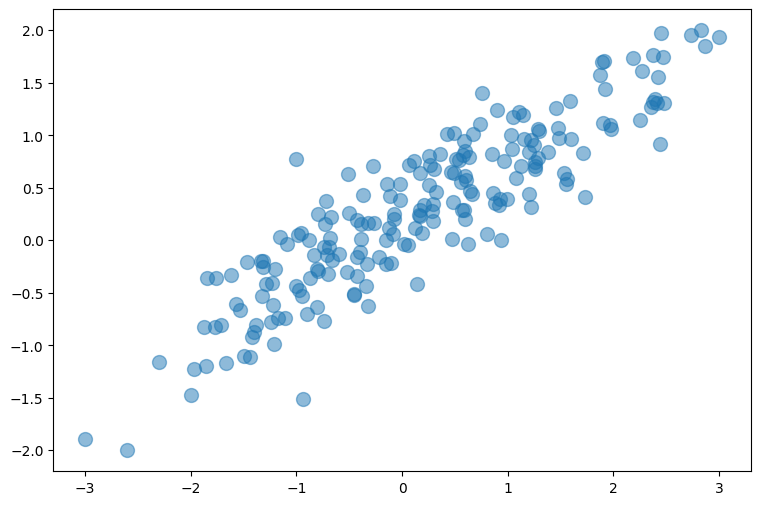

In [4]:
import numpy as np
from sklearn.datasets import make_regression
import matplotlib.pyplot as plt

x, y = make_regression(n_samples=200, n_features=1, noise=50, random_state=0)
x = np.interp(x, (x.min(), x.max()), (-3, 3))
y = np.interp(y, (y.min(), y.max()), (-2, 2))
xy = np.column_stack((x, y))

plt.figure(figsize=(9, 6))
plt.scatter(x, y, s=100, alpha=0.5);

We use PCA (Principal Component Analysis) to find the two principal components in a data set.

In [5]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
pca.fit(xy)

PCA(n_components=2)

Now let's plot the two principal components. The first component is the axis that contains most of the information. The second component is the axis that contains the residual information. Since the data points roughly form a line, the first component lies along that line.

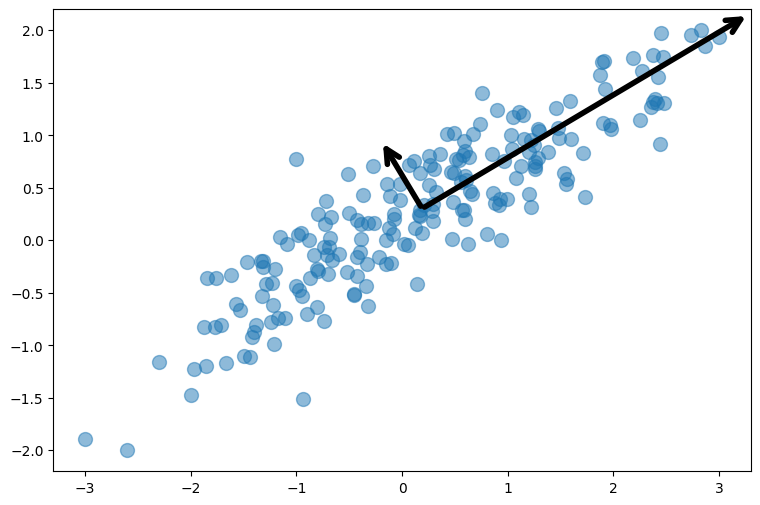

In [6]:
def draw_vector(v0, v1):
    ax = plt.gca()
    props = dict(arrowstyle='->', linewidth=4, mutation_scale=25)
    ax.annotate('', v1, v0, arrowprops=props)

plt.figure(figsize=(9, 6))
plt.scatter(x, y, s=100, alpha=0.5)

for len_, vector in zip(pca.explained_variance_, pca.components_):
    draw_vector(pca.mean_, pca.mean_ + (vector * 2.5 * np.sqrt(len_)))

Let's use the `explained_variance_ratio_` attribute of the `PCA` class to quantify the amount of information contained in each component.

In [7]:
pca.explained_variance_ratio_

array([0.95860561, 0.04139439])

More than 95% of the information in the data set is contained on a single axis (principal component). Let's use PCA (Principal Component Analysis) to reduce the data set to a single principal component.

In [8]:
pca = PCA(n_components=1)
pca_data = pca.fit_transform(xy)

Now we project all the data points onto the principal component axis, inverting the PCA (Principal Component Analysis) transformation, restoring the transformed data to two dimensions with information from the first dimension only. The original points are shown in blue, and the projected points are shown in orange.

In [9]:
pca_data.shape, pca.inverse_transform(pca_data).shape

((200, 1), (200, 2))

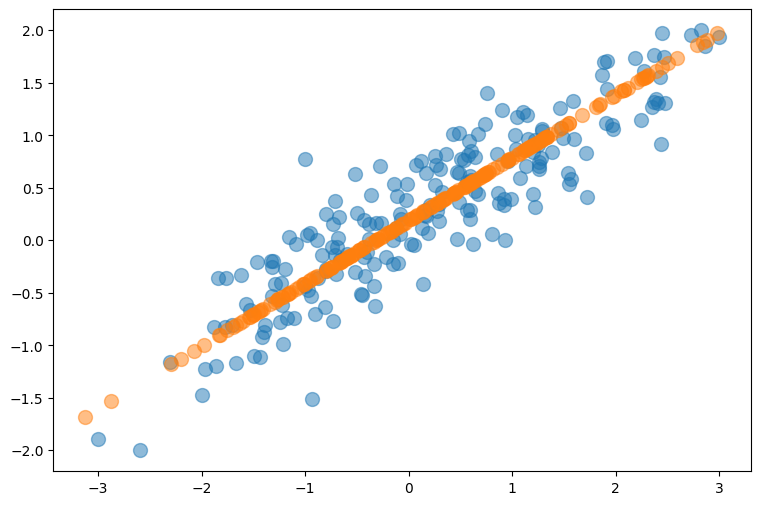

In [10]:
unpca_data = pca.inverse_transform(pca_data)

plt.figure(figsize=(9, 6))
plt.scatter(x, y, s=100, alpha=0.5)
plt.scatter(unpca_data[:, 0], unpca_data[:, 1], s=100, alpha=0.5);

You can see that the orange points retain most of the information contained in the blue points, even though the size of the dataset has been halved (from two dimensions to one). This is the essence of PCA (Principal Component Analysis): reducing the number of dimensions without a corresponding loss of information.

## PCA with face images

An interesting way to visualize how PCA (Principal Component Analysis) can reduce the size of a dataset while preserving most of the information is to apply it to the Labeled Faces in the Wild (LFW) dataset. First, we load the dataset and reduce the number of dimensions by 95%. Then, we invert the PCA transformation to visualize how little of the original information was lost.

In [11]:
from sklearn.datasets import fetch_lfw_people

faces = fetch_lfw_people(min_faces_per_person=100)
print(faces.target_names)
print(faces.images.shape)

['Colin Powell' 'Donald Rumsfeld' 'George W Bush' 'Gerhard Schroeder'
 'Tony Blair']
(1140, 62, 47)


Let's plot the first 24 images in the dataset along with their labels.

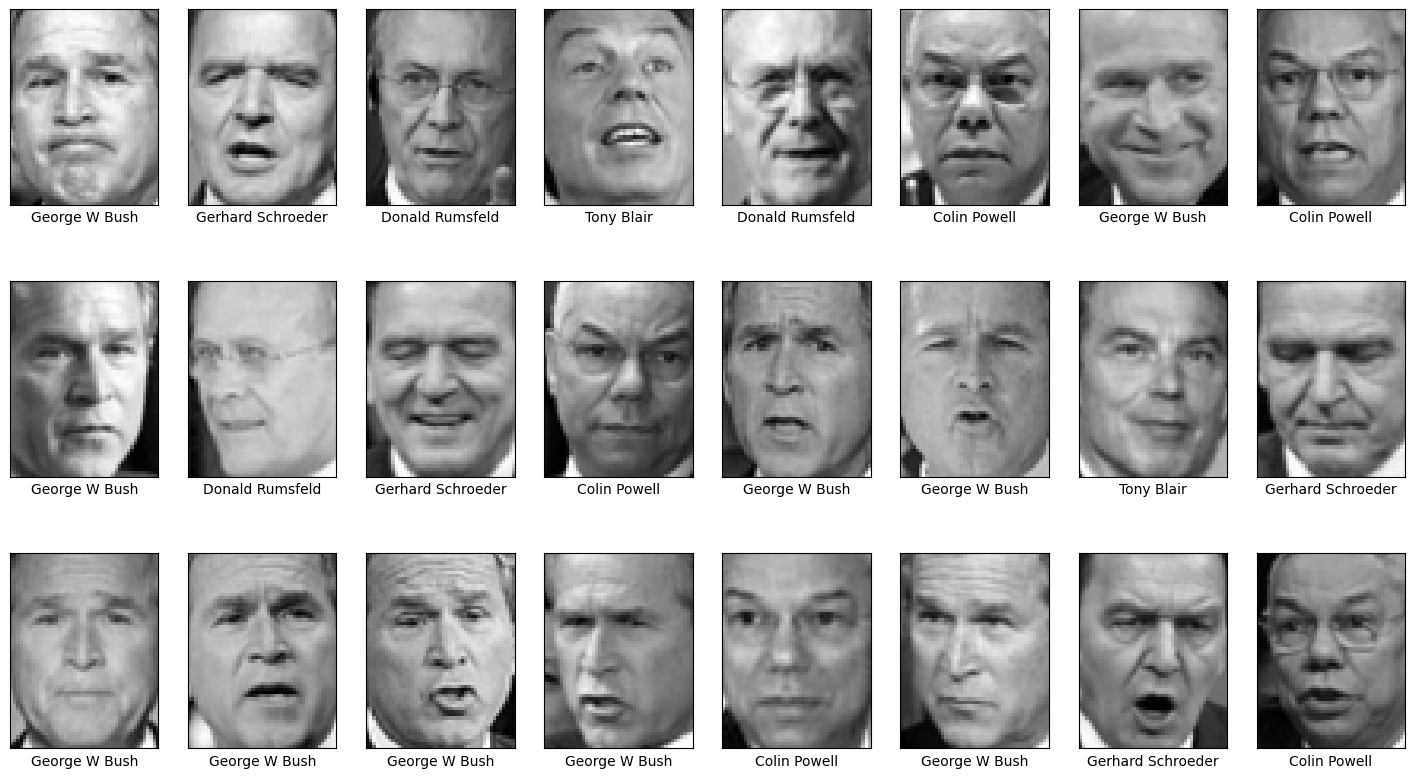

In [12]:
fig, ax = plt.subplots(3, 8, figsize=(18, 10))

for i, axi in enumerate(ax.flat):
    axi.imshow(faces.images[i], cmap='gist_gray')
    axi.set(xticks=[], yticks=[], xlabel=faces.target_names[faces.target[i]])

Now we reduce the 2,914 dimensions (62 x 47) to 150 using PCA (Principal Component Analysis) and invert the transformation to recover the face images.

In [13]:
pca = PCA(n_components=150, random_state=0)
pca_faces = pca.fit_transform(faces.data)
unpca_faces = pca.inverse_transform(pca_faces).reshape(1140, 62, 47)

pca_faces.shape, unpca_faces.shape

((1140, 150), (1140, 62, 47))

Restored facial images:

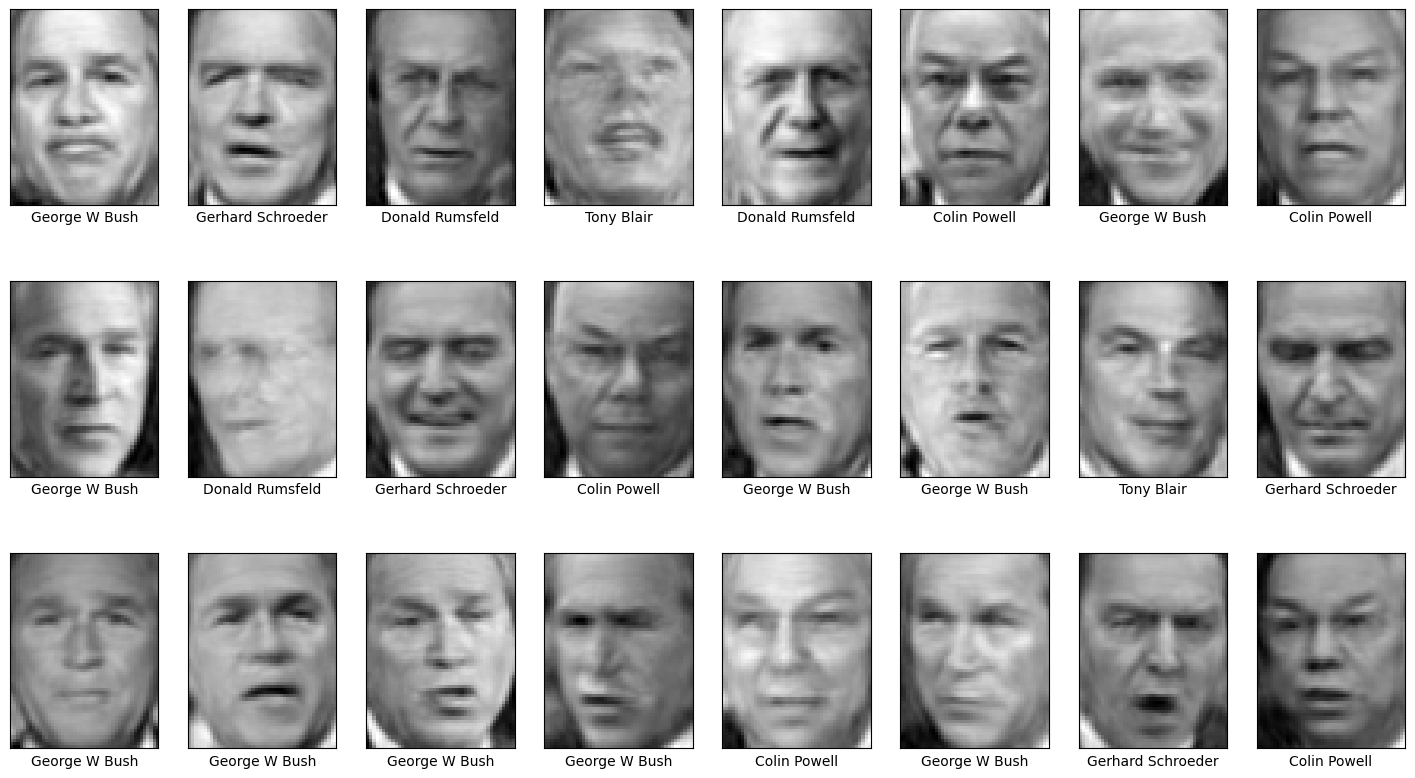

In [14]:
fig, ax = plt.subplots(3, 8, figsize=(18, 10))

for i, axi in enumerate(ax.flat):
    axi.imshow(unpca_faces[i], cmap='gist_gray')
    axi.set(xticks=[], yticks=[], xlabel=faces.target_names[faces.target[i]])

Compare the before and after images. Does it look like 95% of the information was discarded? In fact, you can calculate how much of the original information was retained by summing the explained variances. In this case, it's almost 95%:

In [15]:
np.sum(pca.explained_variance_ratio_), len(pca.explained_variance_ratio_)

(np.float32(0.9383234), 150)

A logical question to ask is what is the "right" number of components? In other words, what number of components provides the best balance between reducing the number of dimensions in the dataset and preserving the most information? One way to answer this question is with a scree plot, which shows the proportion of variance explained by each dimension. Here is a scree plot for a PCA transformation used on images of faces.

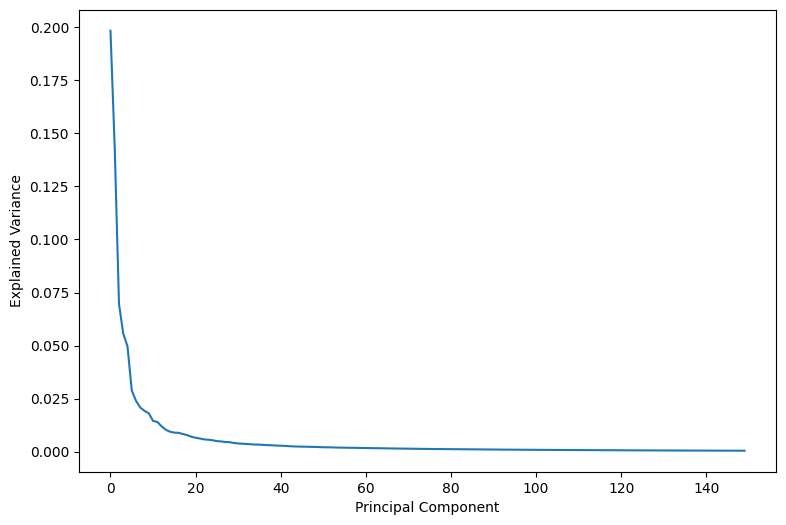

In [16]:
plt.figure(figsize=(9, 6))
plt.plot(pca.explained_variance_ratio_)
plt.xlabel('Principal Component')
plt.ylabel('Explained Variance');

Another way to look at this is to plot the sum of explained variances as a function of the number of components.

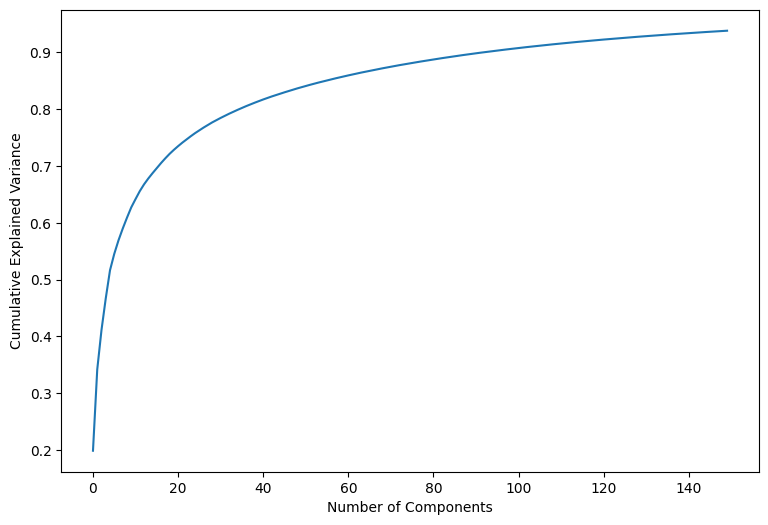

In [17]:
plt.figure(figsize=(9, 6))
plt.plot(np.cumsum(pca.explained_variance_ratio_))
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance');

Let's visualize the result for the same image for different number of components

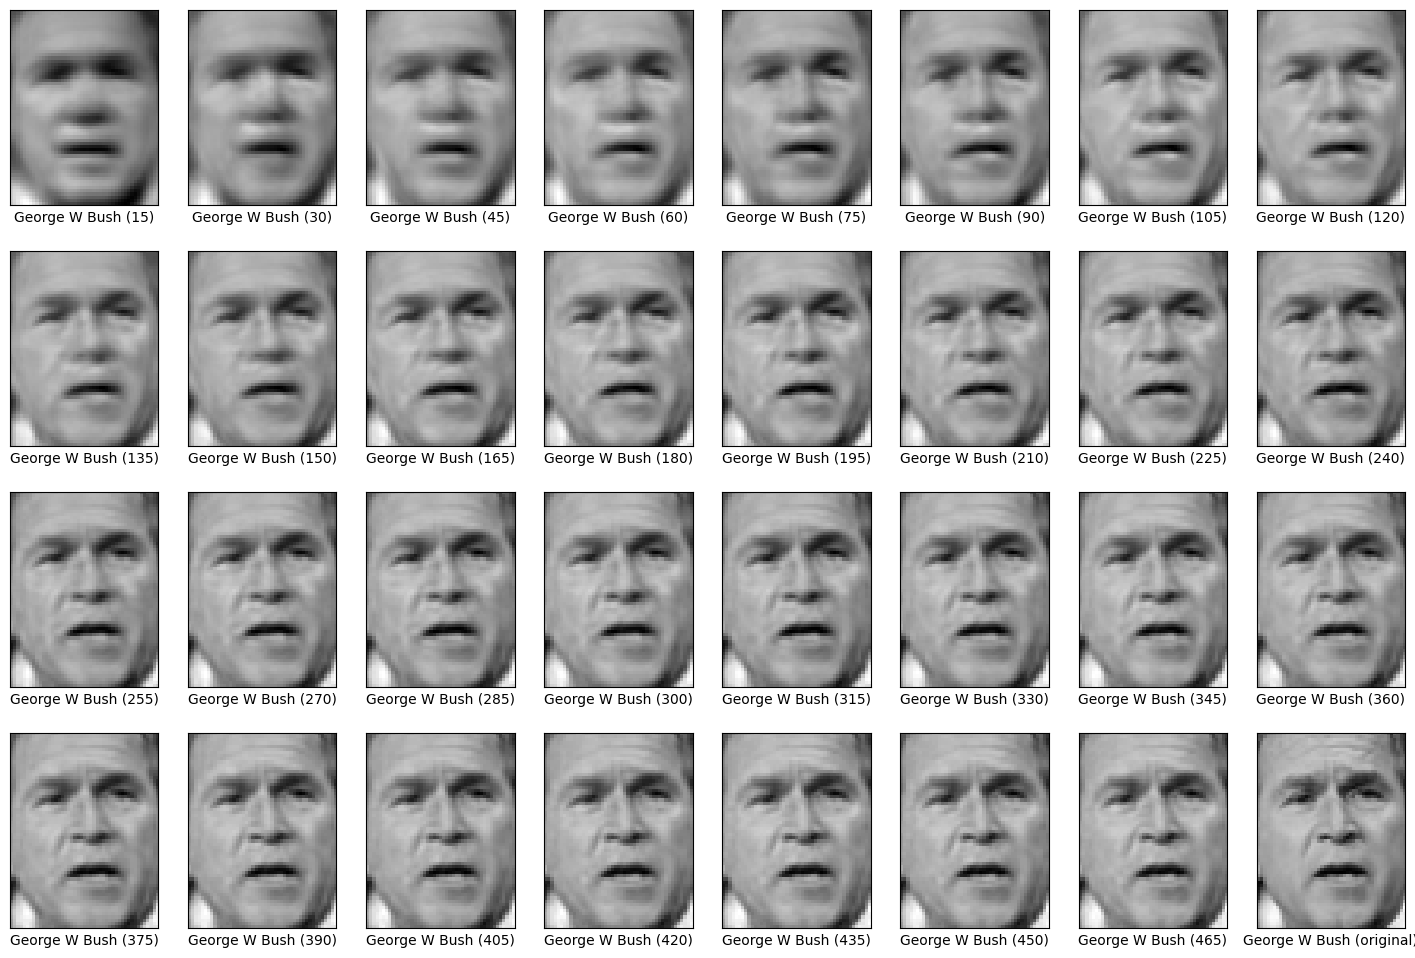

In [18]:
img_idx = 17
step = 15

fig, ax = plt.subplots(4, 8, figsize=(18, 12))

for i, axi in enumerate(ax.flat):
    pca_components = (i+1)*step
    # reduce dimensions
    pca = PCA(n_components=pca_components, random_state=0)
    pca_faces = pca.fit_transform(faces.data)
    # restore image in original dimension from reduced one
    unpca_faces = pca.inverse_transform(pca_faces).reshape(1140, 62, 47)

    # plot result
    if i < 31:
        axi.imshow(unpca_faces[img_idx], cmap='gist_gray')
        axi.set(xticks=[], yticks=[], xlabel=faces.target_names[faces.target[img_idx]] + f' ({pca_components})')
    # plot original image if last iteration
    else:
        axi.imshow(faces.images[img_idx], cmap='gist_gray')
        axi.set(xticks=[], yticks=[], xlabel=faces.target_names[faces.target[img_idx]] + ' (original)')

## Using PCA in Practice: Noise Reduction

One practical application of PCA is filtering noise from data. The basic approach is to transform a dataset using PCA and then perform the inverse transformation, transforming the dataset from *m* dimensions to *n* and then back to *m*. Here we demonstrate this by artificially adding noise to the handwritten digit dataset included with Scikit-learn. This dataset contains 1,797 images, each of which is an 8x8 array of numbers, totaling 64 dimensions. We start by loading the dataset and displaying the first 50 images.

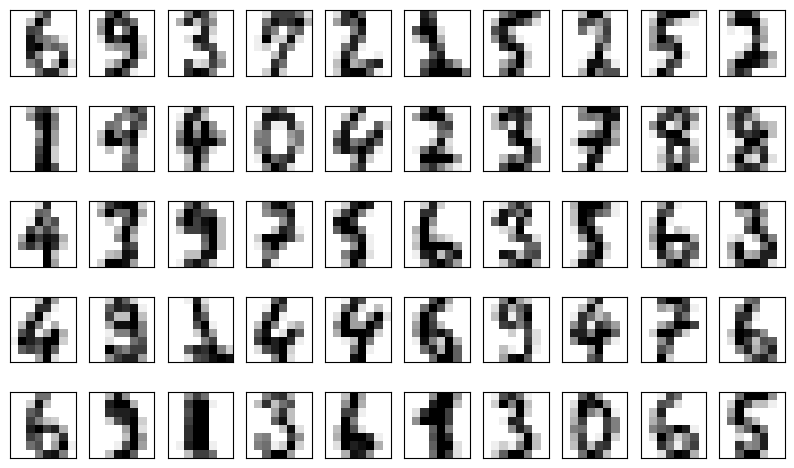

In [19]:
from sklearn.datasets import load_digits

digits = load_digits()
fig, axes = plt.subplots(5, 10, figsize=(10, 6), subplot_kw={'xticks': [], 'yticks': []})

np.random.seed(42)
indexes = np.random.choice(len(digits.images), 50, replace=False)

for i, ax in enumerate(axes.flat):
    ax.imshow(digits.images[indexes[i]], cmap=plt.cm.gray_r)

Introduce random noise into the data set and plot the results.

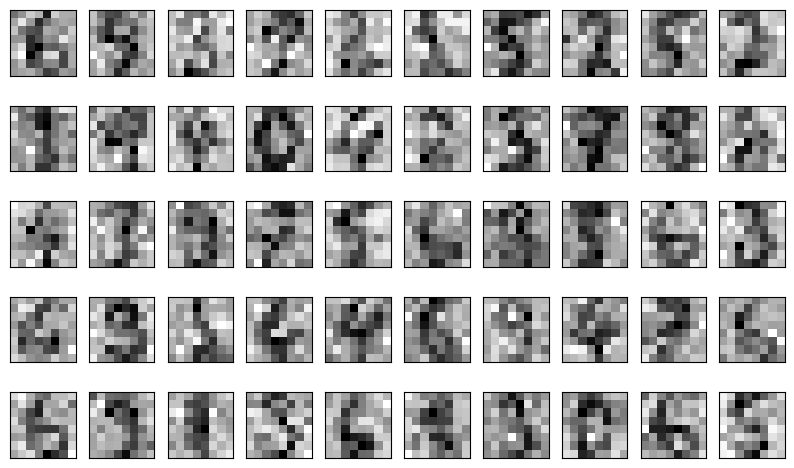

In [20]:
np.random.seed(42)
noisy = np.random.normal(digits.data, 4)
fig, axes = plt.subplots(5, 10, figsize=(10, 6), subplot_kw={'xticks': [], 'yticks': []})

for i, ax in enumerate(axes.flat):
    ax.imshow(noisy[indexes[i]].reshape(8, 8), cmap=plt.cm.gray_r)

Let's use PCA to reduce the number of dimensions. Instead of specifying the number of dimensions (components), we'll specify that we want to reduce the amount of information in the dataset to 50%. We'll let Scikit learn decide how many dimensions remain, and then display the number of dimensions.

In [21]:
pca = PCA(0.5, random_state=0).fit(noisy)
pca.n_components_

np.int64(12)

PCA reduced the number of dimensions from 64 to 12, but the 12 remaining dimensions contain 50% of the information from the original 64. Now we reconstruct the dataset from the reduced version.

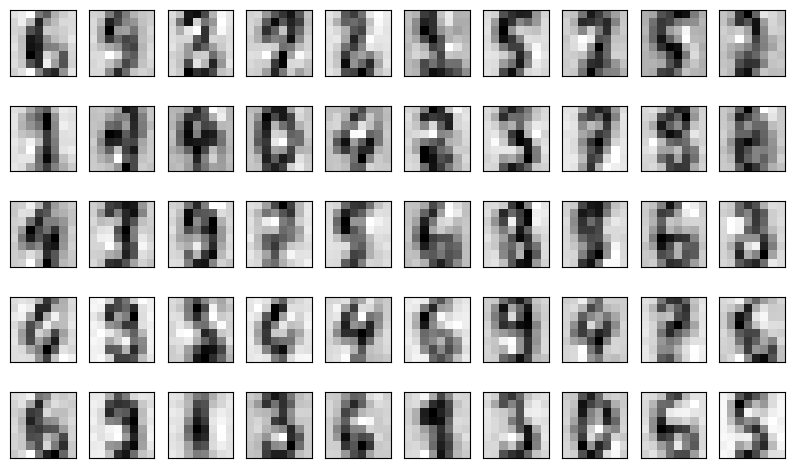

In [22]:
pca_digits = pca.transform(noisy)
unpca_digits = pca.inverse_transform(pca_digits)

fig, axes = plt.subplots(5, 10, figsize=(10, 6), subplot_kw={'xticks': [], 'yticks': []})

for i, ax in enumerate(axes.flat):
    ax.imshow(unpca_digits[indexes[i]].reshape(8, 8), cmap=plt.cm.gray_r)

The recovered dataset is not as clean as the original, but it is clean enough to make out most of the numbers.

## Visualizing Multidimensional Data

Another practical application of PCA (Principal Component Analysis) is in visualizing multidimensional data. Most machine learning models are trained on datasets that contain many dimensions. For example, a dataset of 100x100 pixels of images contains 10,000 dimensions. Humans can only visualize data in two or at most three dimensions. Using PCA to reduce hundreds (or thousands) of dimensions to two or three, and then plotting the reduced dataset, helps us visualize clusters of data in multidimensional datasets. We will demonstrate this by using PCA to reduce the numbers used in the previous example first to two and then to three dimensions and plotting the results.

Let’s start by loading the dataset, reducing it to two dimensions, and plotting the result.

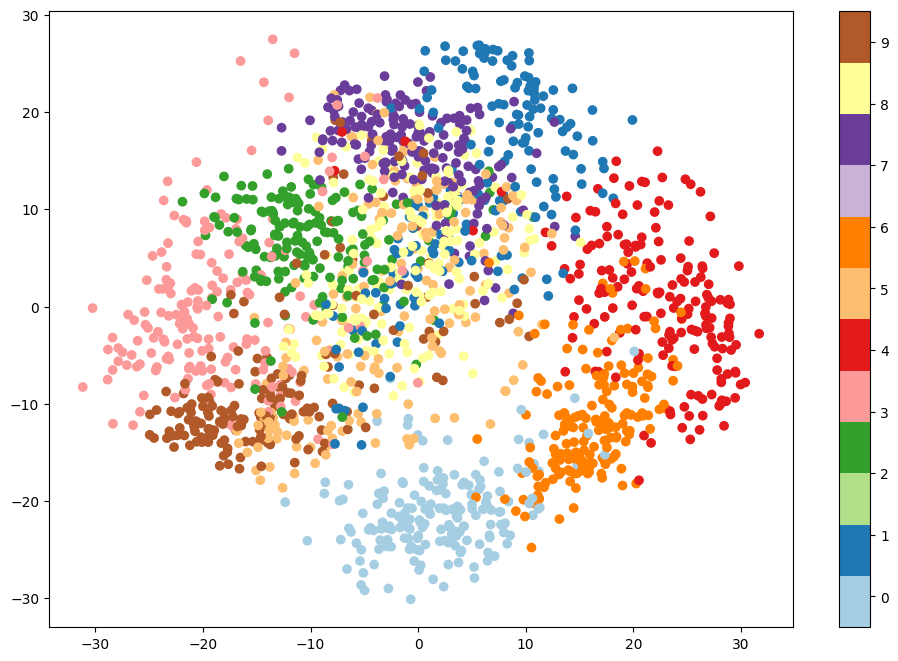

In [23]:
digits = load_digits()
pca = PCA(n_components=2, random_state=0)
pca_digits = pca.fit_transform(digits.data)

plt.figure(figsize=(12, 8))
plt.scatter(pca_digits[:, 0], pca_digits[:, 1], c=digits.target, cmap='Paired')
plt.colorbar(ticks=range(10))
plt.clim(-0.5, 9.5)

Reduced to two dimensions, the numbers form somewhat distinct clusters, although with some overlap. 0, represented by the light blue dots, appears to have little overlap with the other numbers, while 9 and 5 show some similarity, at least when viewed in two dimensions. Let's try reducing the data set to three dimensions instead of two to see if additional separation is apparent with the additional dimension.

### 3D Visualizations

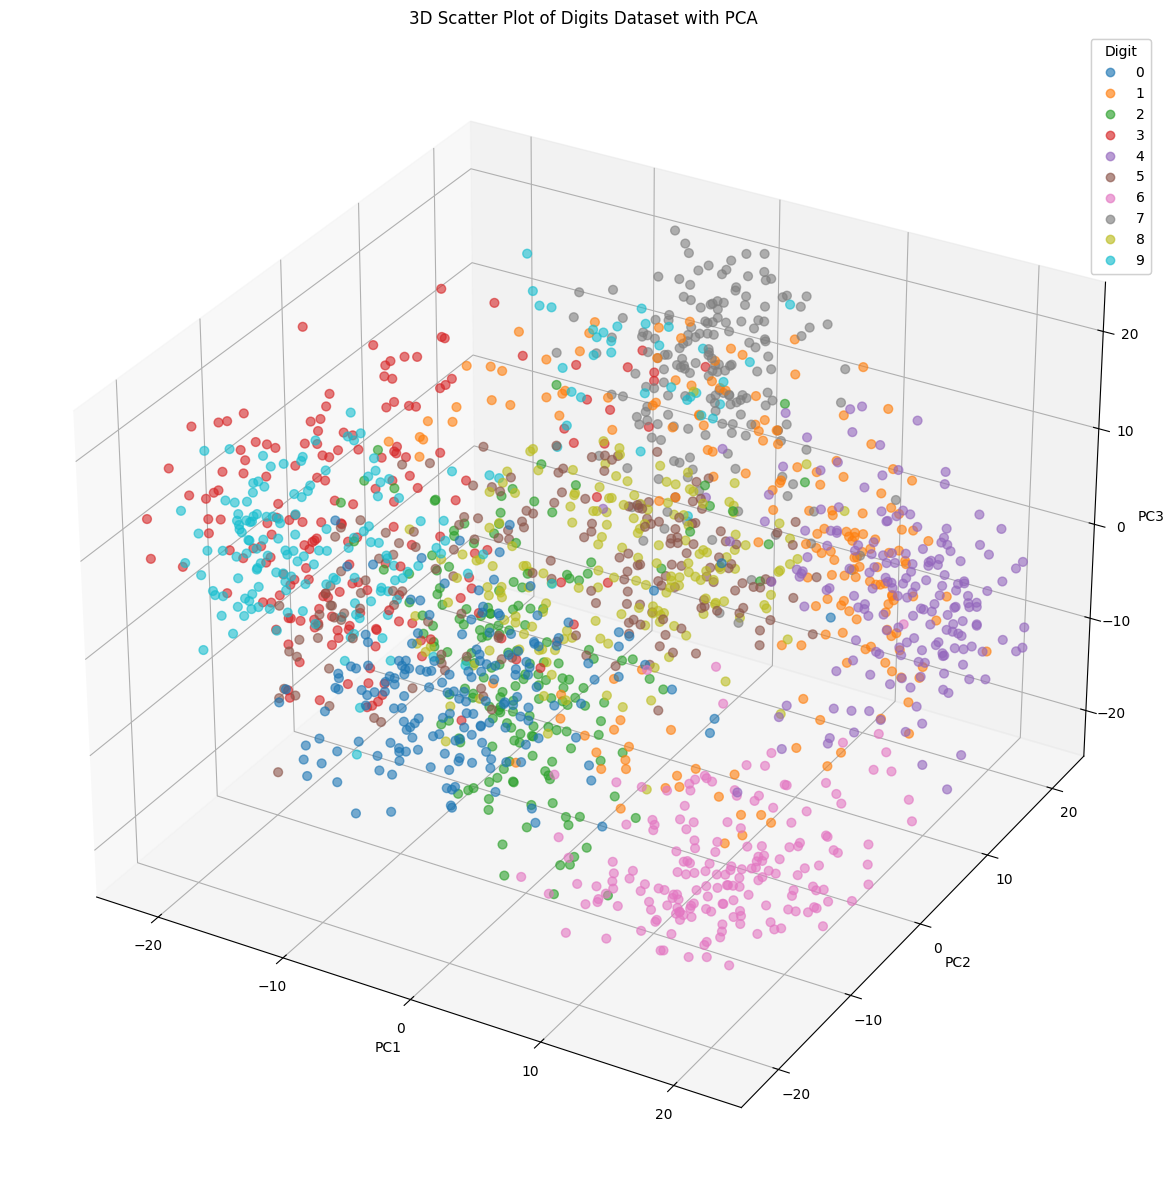

In [24]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.datasets import load_digits
import numpy as np

# Load data
digits = load_digits()

# PCA to 3 components
pca = PCA(n_components=3, random_state=0)
pca_digits = pca.fit_transform(digits.data)

# Create DataFrame
df = pd.DataFrame(pca_digits, columns=['PC1', 'PC2', 'PC3'])
df['target'] = digits.target

# Create 3D plot
fig = plt.figure(figsize=(16, 12))
ax = fig.add_subplot(111, projection='3d')

# change initial scale
limit = 25
ax.set_xlim(-limit, limit)
ax.set_ylim(-limit, limit)
ax.set_zlim(-limit, limit)

# Use a colormap for different digit classes
scatter = ax.scatter(
    df['PC1'],
    df['PC2'],
    df['PC3'],
    c=df['target'],
    cmap='tab10',
    s=40,
    alpha=0.6
)

# Labels and title
ax.set_title('3D Scatter Plot of Digits Dataset with PCA')
ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
ax.set_zlabel('PC3')
# ax.view_init(elev=20, azim=45)

# Create legend from scatter colors
legend = ax.legend(
    *scatter.legend_elements(),
    title="Digit"
)
ax.add_artist(legend)

plt.tight_layout()
plt.show()

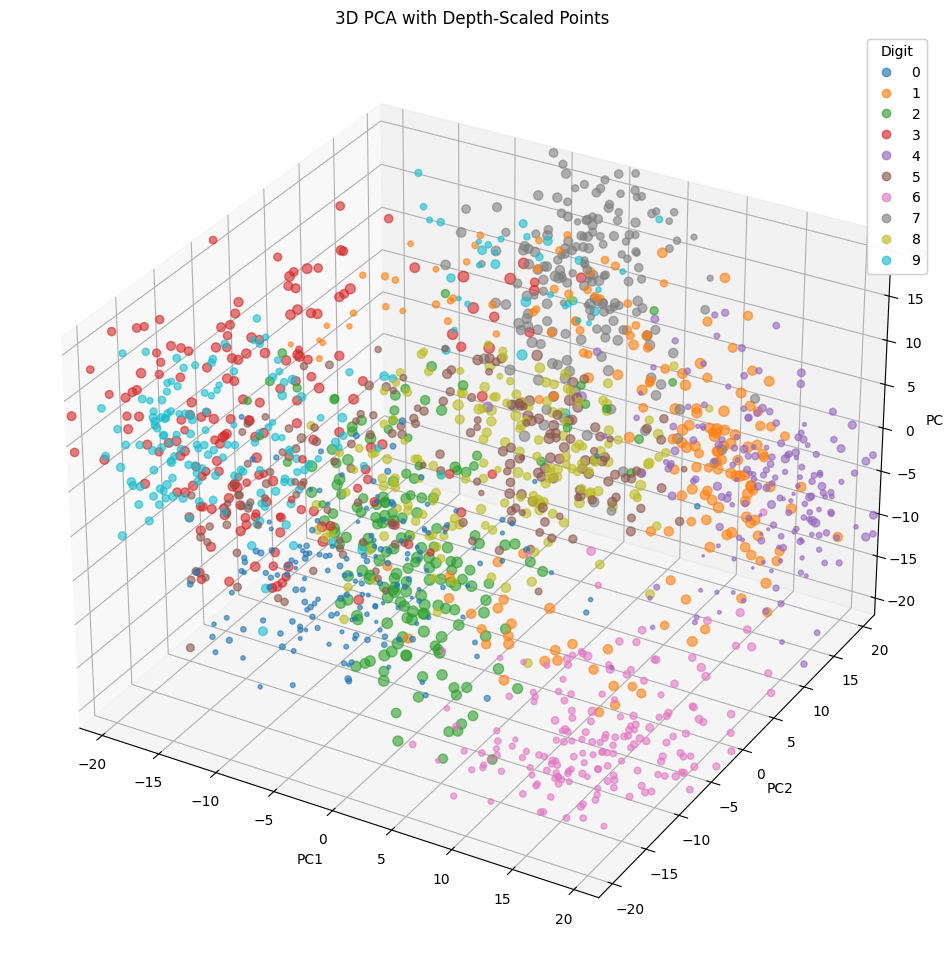

In [25]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401
from sklearn.decomposition import PCA
from sklearn.datasets import load_digits

# Data + PCA
digits = load_digits()
pca = PCA(n_components=3, random_state=0)
X = pca.fit_transform(digits.data)
y = digits.target

fig = plt.figure(figsize=(16, 12))
ax = fig.add_subplot(111, projection='3d')

# change initial scale
limit = 22
ax.set_xlim(-limit, limit)
ax.set_ylim(-limit, limit)
ax.set_zlim(-limit, limit)

# Initial scatter (sizes will be updated later)
sc = ax.scatter(X[:, 0], X[:, 1], X[:, 2],
                c=y, cmap='tab10', alpha=0.6)

ax.set_title('3D PCA with Depth-Scaled Points')
ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
ax.set_zlabel('PC3')


def update_sizes(event=None):
    # Get camera angles
    elev = np.deg2rad(ax.elev)
    azim = np.deg2rad(ax.azim)

    # Camera direction vector
    cam_dir = np.array([
        np.cos(elev) * np.cos(azim),
        np.cos(elev) * np.sin(azim),
        np.sin(elev)
    ])

    # Project points onto camera direction (depth)
    depth = X @ cam_dir

    # Normalize depth to [0, 1]
    depth_norm = (depth - depth.min()) / (depth.max() - depth.min())

    # Invert so closer points are larger
    sizes = 3 + (1 - depth_norm) * 60

    sc.set_sizes(sizes)
    fig.canvas.draw_idle()

legend = ax.legend(
    *scatter.legend_elements(),
    title="Digit"
)
ax.add_artist(legend)

# Update sizes whenever the view changes (mouse rotate)
fig.canvas.mpl_connect('motion_notify_event', update_sizes)

# Initial sizing
update_sizes()

plt.show()

In [26]:
import pandas as pd
import plotly.express as px

pca = PCA(n_components=3, random_state=0)
pca_digits = pca.fit_transform(digits.data)

# Create a DataFrame for Plotly Express
df = pd.DataFrame(data=pca_digits, columns=['PC1', 'PC2', 'PC3'])
df['target'] = digits.target

# Create an interactive 3D scatter plot
fig = px.scatter_3d(
    df,
    x='PC1',
    y='PC2',
    z='PC3',
    hover_data='target',
    color='target',
    title='3D Scatter Plot of Digits Dataset with PCA'
)

# Show the figure
fig.show()